# Live surface

This notebook builds the IV surface from the same sample snapshot `02_iv_solver.ipynb` used, then looks at where our solved IV disagrees with Yahoo's own reported IV. No internet needed.

In [1]:
import sys

sys.path.insert(0, "..")  # optionsengine lives one level up, next to notebooks/

import pandas as pd
import matplotlib.pyplot as plt
import plotly.io as pio
from optionsengine import config
from optionsengine.quotes import clean_quotes
from optionsengine.validation import add_our_iv, add_error, add_moneyness_bucket, mae_rmse, mae_rmse_by
from optionsengine.surface import add_log_moneyness, build_surface
from optionsengine.plotting import plot_surface, plot_smiles, plot_term_structure

# GitHub can't run the JS behind an interactive Plotly figure, so bake a static image
# instead. The real interactive version comes from scripts/live_surface.py.
pio.renderers.default = "png"

## Load, clean, solve

Same first steps as `02_iv_solver.ipynb`. Load the sample snapshot, clean it, and solve our own IV for each quote.

In [2]:
raw = pd.read_csv("../data/snapshots/sample_spx_20260827_1349.csv")
raw["asof"] = pd.to_datetime(raw["asof"])

quotes = clean_quotes(raw, weekly_root=config.ACTIVE.weekly_root,
                       monthly_root=config.ACTIVE.monthly_root,
                       am_hour=config.AM_SETTLEMENT_HOUR, pm_hour=config.PM_SETTLEMENT_HOUR,
                       r=config.r)
quotes = add_our_iv(quotes, config.r)
quotes = add_log_moneyness(quotes)
print(f"{len(quotes)} quotes solved")

5802 quotes solved


## The surface

Each expiry gets its own smile, interpolated with a PCHIP spline onto a shared log-moneyness grid. The smiles are then stacked in order of expiry to make the surface.

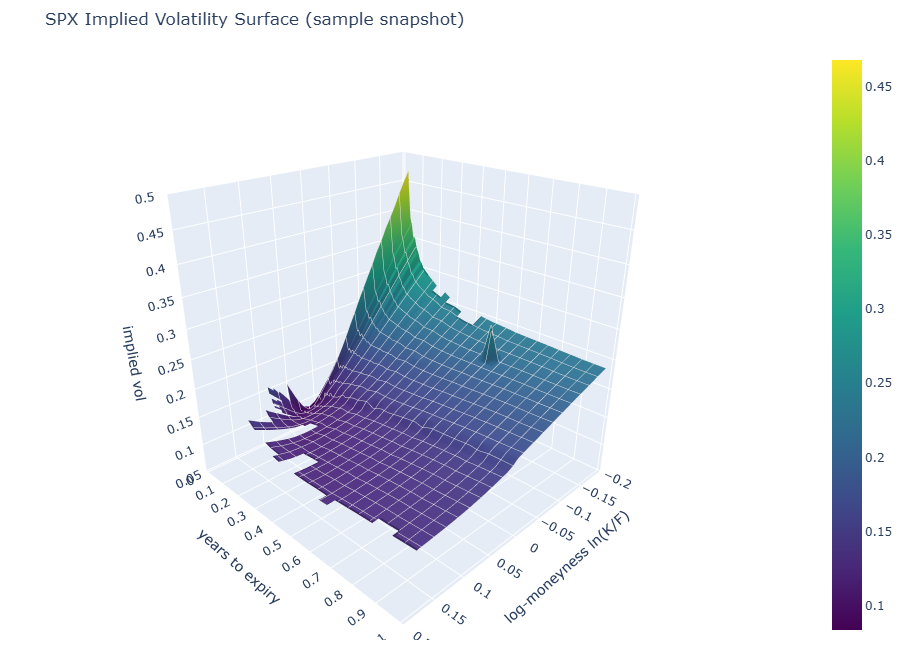

In [3]:
surface = build_surface(quotes, iv_column="iv_ours")
fig = plot_surface(surface, title=f"{config.ACTIVE_SYMBOL} Implied Volatility Surface (sample snapshot)")
fig.show()

## Smiles and term structure

A few of the individual smiles, and the at-the-money vol plotted against time to expiry.

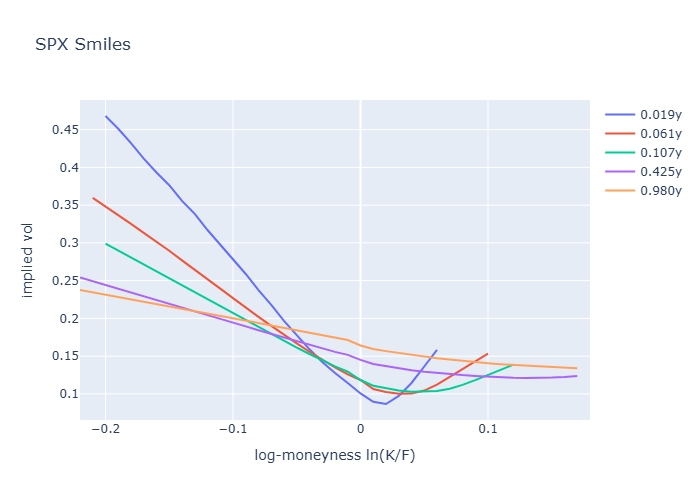

In [4]:
years = sorted(surface.index)
picks = [years[i] for i in (0, len(years) // 4, len(years) // 2, 3 * len(years) // 4, -1)]

fig = plot_smiles(surface, years_to_expiry=picks, title=f"{config.ACTIVE_SYMBOL} Smiles")
fig.show()

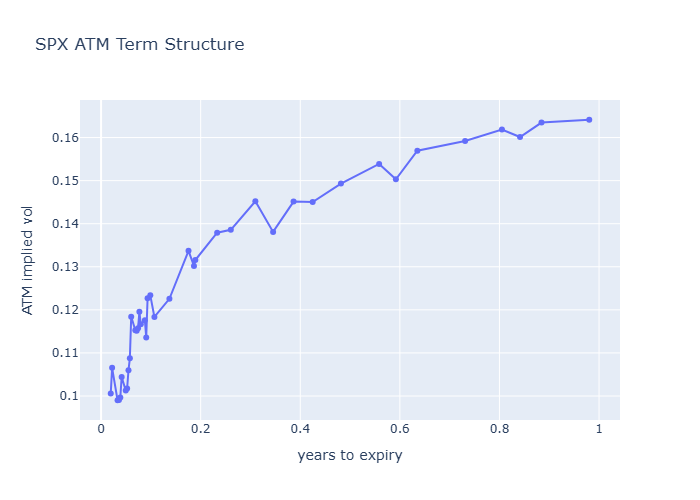

In [5]:
fig = plot_term_structure(surface, title=f"{config.ACTIVE_SYMBOL} ATM Term Structure")
fig.show()

The ATM volatility rises from about 10% a few weeks out to about 16% at one year. An upward slope like this is the normal shape in a calm market. The near term is expected to stay quiet, so it trades at a low volatility, while longer-dated options carry more uncertainty and trade higher. A downward slope tends to show up instead when the market is stressed and the near term is where the risk is.

## Compare to Yahoo's IV

This is not a clean test of the model on its own. We do not know how Yahoo computes its IV, and it may be based on a slightly earlier price than the bid/ask next to it. So any gap could come from our model, from Yahoo's method, or from a timing difference.

In [6]:
quotes = add_error(quotes)
quotes = add_moneyness_bucket(quotes)

mae, rmse = mae_rmse(quotes)
print(f"overall MAE  = {mae:.4f}")
print(f"overall RMSE = {rmse:.4f}")

overall MAE  = 0.0155
overall RMSE = 0.0185


An MAE of 0.0155 means our solved volatility is about 1.5 volatility points away from Yahoo's on average. Most quotes in this snapshot are around 15% volatility, so the difference is roughly 10% of the level. The gap is not the same everywhere in the chain. The rest of the notebook works out where it comes from.

## The error has no simple shape across strikes

Grouping the error by moneyness bucket does not give a simple story. In this snapshot it rises through the put side, peaks just below the money, drops on the call side, then ticks back up at the far out-of-the-money call wing. It is not a clean symmetric hump, and it is not monotonic either.

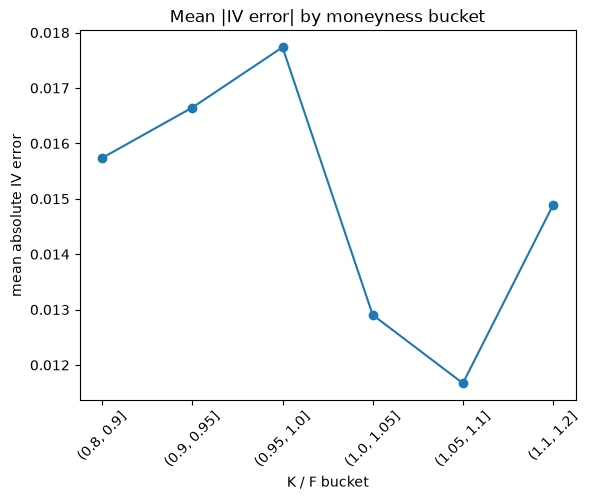

In [7]:
by_bucket = mae_rmse_by(quotes, "moneyness_bucket").sort_index()

fig, ax = plt.subplots()
ax.plot(by_bucket.index.astype(str), by_bucket["mae"], marker="o")
ax.set_title("Mean |IV error| by moneyness bucket")
ax.set_xlabel("K / F bucket")
ax.set_ylabel("mean absolute IV error")
plt.xticks(rotation=45)
plt.show()

## The real driver: a forward mismatch

A better place to look is the exact strike where puts hand off to calls. If both sides are solved the same way, the IV should be roughly continuous across that point.

In [8]:
by_right = quotes.groupby("right")["iv_error"].mean()
print(by_right)

right
C   -0.012647
P    0.016750
Name: iv_error, dtype: float64


Yahoo jumps backwards at the money in 40/40 expiries
We do in 0/40 expiries


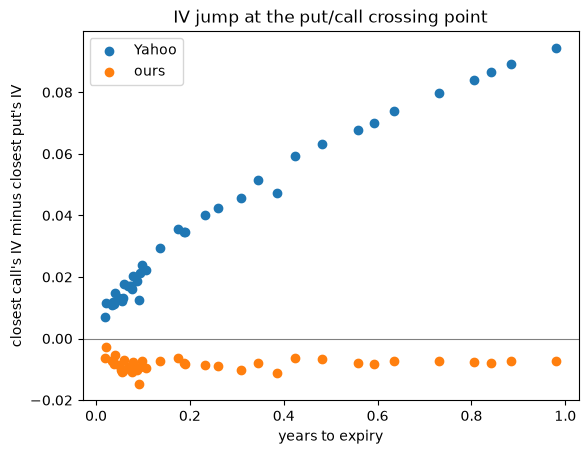

In [9]:
jumps = []
for years, group in quotes.groupby("years_to_expiry"):
    puts = group[group["right"] == "P"].sort_values("strike")
    calls = group[group["right"] == "C"].sort_values("strike")
    if puts.empty or calls.empty:
        continue
    jumps.append({
        "years": years,
        "jump_yahoo": calls.iloc[0]["implied_vol_yahoo"] - puts.iloc[-1]["implied_vol_yahoo"],
        "jump_ours": calls.iloc[0]["iv_ours"] - puts.iloc[-1]["iv_ours"],
    })
jumps = pd.DataFrame(jumps)
print(f"Yahoo jumps backwards at the money in {(jumps['jump_yahoo'] > 0).sum()}/{len(jumps)} expiries")
print(f"We do in {(jumps['jump_ours'] > 0).sum()}/{len(jumps)} expiries")

fig, ax = plt.subplots()
ax.scatter(jumps["years"], jumps["jump_yahoo"], label="Yahoo")
ax.scatter(jumps["years"], jumps["jump_ours"], label="ours")
ax.axhline(0, color="grey", linewidth=0.8)
ax.set_title("IV jump at the put/call crossing point")
ax.set_xlabel("years to expiry")
ax.set_ylabel("closest call's IV minus closest put's IV")
ax.legend()
plt.show()

Our IV stays smooth through the money, which makes sense since both sides are solved the same way. Yahoo's IV jumps backwards there every time, and the jump gets bigger the further out the expiry is. That is not random noise. It is what happens when calls and puts are priced against different forwards. A gap in the assumed cost of carry would cause exactly this, growing with time the way we see here.

## How much is the dividend, and how much is the rate

This project prices with a 4% rate and no dividend. To see which assumption drives the gap with Yahoo, we re-solve at four combinations of the two. The solver takes a single rate, so a dividend `q` goes in as `r - q`.

In [10]:
from optionsengine.implied_vol import implied_vol as _implied_vol

# Each case feeds a different effective rate (r - q) to the solver.
cases = {
    "r = 4%, no dividend (our model)": 0.04,
    "r = 4%, 1.04% dividend": 0.04 - 0.0104,
    "no rate, 1.04% dividend": -0.0104,
    "no rate, no dividend": 0.0,
}

for label, rate in cases.items():
    iv = quotes.apply(
        lambda row: _implied_vol(row["mid"], row["underlying_price"], row["strike"],
                                  row["years_to_expiry"], rate, row["right"]).iv,
        axis=1,
    )
    mae = (iv - quotes["implied_vol_yahoo"]).abs().mean()
    print(f"{label:<33}  MAE = {mae:.4f}")

r = 4%, no dividend (our model)    MAE = 0.0155


r = 4%, 1.04% dividend             MAE = 0.0119


no rate, 1.04% dividend            MAE = 0.0044


no rate, no dividend               MAE = 0.0019


Dropping the 4% rate is what closes the gap, not the dividend. With the rate gone and no dividend the MAE falls to 0.0019. Adding the real 1% dividend on top of that makes it slightly worse, because it pushes the forward below spot and Yahoo seems to use spot exactly.

So Yahoo looks like it inverts Black-Scholes with no rate and no dividend at all. That is not more correct than pricing off the forward. It just lines up with Yahoo's own shortcut, so the forward stays in our model (see the README).

This also explains the bump in the earlier bucket plot. Buckets below `K/F = 1` hold almost only puts, and buckets above it almost only calls. Our put errors and call errors have opposite signs. The bucket plot just walks from one group to the other. The peak is where they meet.